In [16]:
import pandas as pd
import pyterrier as pt
if not pt.started():
    pt.init()

/tmp/ipykernel_6854/3658901313.py:3: DeprecationWarning: Call to deprecated function (or staticmethod) started. (use pt.java.started() instead) -- Deprecated since version 0.11.0.
  if not pt.started():


In [17]:
lhs_run_path = "/nfs/primary/SPLADE/splade_class/first_stage_retrieval/runs/intermediates/splade_distil % 1000"
middle_run_path = "/nfs/primary/SPLADE/splade_class/first_stage_retrieval/runs/intermediates/splade_distil % 1000 >> filter % 100"
rhs_run_path = "/nfs/primary/SPLADE/splade_class/first_stage_retrieval/runs/intermediates/splade_distil % 1000 >> filter % 100 >> get_text >> monot5_sans"

lhs_run = pt.io.read_results(lhs_run_path)
middle_run = pt.io.read_results(middle_run_path)
rhs_run = pt.io.read_results(rhs_run_path)

qid = "1"

In [18]:
ohsumed_docs = pd.read_pickle("/nfs/primary/sas_reranker/ohsumed_docs_w_t5base_sensitivity.pkl")
queries = pd.read_pickle("/nfs/primary/graph_adaptive_reranking/queries.pkl")
qrels = pd.read_pickle("/nfs/primary/graph_adaptive_reranking/qrels.pkl")

lhs_run = pd.merge(pd.merge(lhs_run, ohsumed_docs, on = "docno"), qrels, on = ["qid", "docno"], how = "left").fillna(0)
middle_run = pd.merge(pd.merge(middle_run, ohsumed_docs, on = "docno"), qrels, on = ["qid", "docno"], how = "left").fillna(0)
rhs_run = pd.merge(pd.merge(rhs_run, ohsumed_docs, on = "docno"), qrels, on = ["qid", "docno"], how = "left").fillna(0)

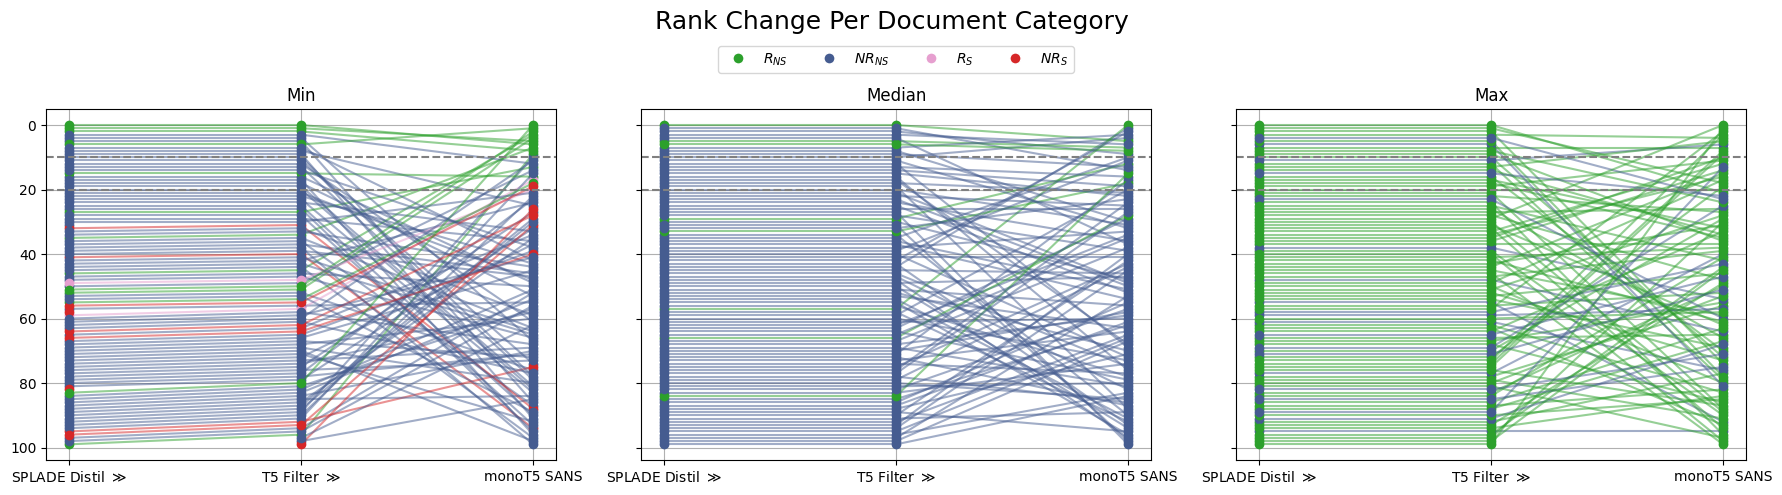

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def get_label_sensitivity_category(label, sensitivity):
    if label > 0 and sensitivity > 0:
        return 'R-S'
    elif label > 0 and sensitivity == 0:
        return 'R-NS'
    elif label == 0 and sensitivity > 0:
        return 'NR-S'
    else:
        return 'NR-NS'

def plot_rank_changes_for_qid(lhs, middle, rhs, qid, k, ax, title):
    lhs_qid = lhs[lhs["qid"] == str(qid)].sort_values("rank").head(k)
    middle_qid = middle[middle["qid"] == str(qid)].sort_values("rank").head(k)
    rhs_qid = rhs[rhs["qid"] == str(qid)].sort_values("rank").head(k)

    meta = pd.concat([lhs_qid, middle_qid, rhs_qid]).drop_duplicates('docno')
    meta_info = meta.set_index("docno")[["label", "sensitivity"]].to_dict(orient="index")

    lhs_dict = dict(zip(lhs_qid['docno'], lhs_qid['rank']))
    middle_dict = dict(zip(middle_qid['docno'], middle_qid['rank']))
    rhs_dict = dict(zip(rhs_qid['docno'], rhs_qid['rank']))

    all_docnos = set(lhs_dict) | set(middle_dict) | set(rhs_dict)

    final_dict = {}
    for docno in all_docnos:
        lhs_rank = lhs_dict.get(docno, np.nan)
        middle_rank = middle_dict.get(docno, np.nan)
        rhs_rank = rhs_dict.get(docno, np.nan)
        final_dict[docno] = [lhs_rank, middle_rank, rhs_rank]
    
    color_map = {
        'R-NS': '#2ca02c',   # Green
        'NR-NS': '#0752FF',  # Yellow
        'R-S': '#ff7f0e',    # Orange
        'NR-S': '#d62728'   # Red
    }
    color_map = {
        'R-NS': '#2ca02c',   # Green
        'NR-NS': '#455C90',  # Yellow
        'R-S': '#E69FCF',    # Orange
        'NR-S': '#d62728'   # Red
    }


    x_positions = np.array([0, 1, 2])  # LHS, Middle, RHS

    for docno, (lhs_rank, middle_rank, rhs_rank) in final_dict.items():
        info = meta_info.get(docno, {"label": 0, "sensitivity": 0})
        category = get_label_sensitivity_category(info["label"], info["sensitivity"])
        color = color_map[category]

        ax.plot(x_positions[0], lhs_rank, 'o', color=color)
        ax.plot(x_positions[1], middle_rank, 'o', color=color)
        ax.plot(x_positions[2], rhs_rank, 'o', color=color)

        ax.plot([x_positions[0], x_positions[1]], [lhs_rank, middle_rank], color=color, alpha=0.5)
        ax.plot([x_positions[1], x_positions[2]], [middle_rank, rhs_rank], color=color, alpha=0.5)

    ax.axhline(y=10, color='grey', linestyle='--', linewidth=1.5)
    ax.axhline(y=20, color='grey', linestyle='--', linewidth=1.5)

    ax.set_xticks(x_positions)
    ax.set_xticklabels([r'SPLADE Distil $\gg$', r'T5 Filter $\gg$', r'monoT5 SANS'])
    ax.set_title(title)
    ax.invert_yaxis()
    ax.grid(True)

def plot_rank_changes_three_qids(lhs, middle, rhs, qids, k=100, dpi = 100, path = "./test"):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True, dpi = dpi)

    # for ax, qid in zip(axes, qids):
    #     plot_rank_changes_for_qid(lhs, middle, rhs, qid, k, ax)
    #
    plot_rank_changes_for_qid(lhs, middle, rhs, qids[0], k, axes[0], "Min")
    plot_rank_changes_for_qid(lhs, middle, rhs, qids[1], k, axes[1], "Median")
    plot_rank_changes_for_qid(lhs, middle, rhs, qids[2], k, axes[2], "Max")

    # Legend (once)
    color_map = {
        'R-NS': '#2ca02c',
        'NR-NS': '#ffdd57',
        'R-S': '#ff7f0e',
        'NR-S': '#d62728'
    }
    color_map = {
        'R-NS': '#2ca02c',   # Green
        'NR-NS': '#455C90',  # Yellow
        'R-S': '#E69FCF',    # Orange
        'NR-S': '#d62728'   # Red
    }


    custom_labels = [r'$R_{NS}$', r'$NR_{NS}$', r'$R_{S}$', r'$NR_{S}$']

    legend_elements = [plt.Line2D([0], [0], marker='o', color='w', label=custom_labels[i],
                                  markerfacecolor=color_map[key], markersize=8)
                       for i, key in enumerate(color_map)]

    axes[1].legend(handles=legend_elements, loc='upper center',
                   bbox_to_anchor=(0.5, 1.2), ncol=4, frameon=True)

    fig.suptitle(f'Rank Change Per Document Category', fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 1.03])
    # plt.show()
    # plt.savefig(f"{path}.png", dpi = dpi)
    # plt.savefig(f"{path}.pdf", dpi = dpi)
    
    
plot_rank_changes_three_qids(lhs_run, middle_run, rhs_run, qids=["2", "34", "43"], k=100, dpi = 100, path = "./rank_change_v4")

In [10]:
import pandas as pd
import statistics

# Load your DataFrame (replace this with your actual loading step)
# df = pd.read_csv("your_file.csv")

# Step 1: Filter relevant and non-sensitive
filtered = lhs_run[(lhs_run['label'] > 0) & (lhs_run['sensitivity'] == 0)]

# Step 2: Group by qid and count
counts = filtered.groupby('qid').size().reset_index(name='count')

# Step 3: Compute min, max, median counts
min_count = counts['count'].min()
max_count = counts['count'].max()
median_count = statistics.median(counts['count'])

# Step 4: Get qids for each
min_qids = counts[counts['count'] == min_count]['qid'].tolist()
max_qids = counts[counts['count'] == max_count]['qid'].tolist()
counts['diff_from_median'] = (counts['count'] - median_count).abs()
closest_median_qids = counts[counts['diff_from_median'] == counts['diff_from_median'].min()]['qid'].tolist()

# Step 5: Output
print(f"Min count: {min_count}, QIDs: {min_qids}")
print(f"Max count: {max_count}, QIDs: {max_qids}")
print(f"Median count: {median_count}, QIDs: {closest_median_qids}")

Min count: 1, QIDs: ['24', '28', '29', '85', '87', '93']
Max count: 121, QIDs: ['43']
Median count: 16.5, QIDs: ['34', '4']


/tmp/ipykernel_6854/1254025603.py:76: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


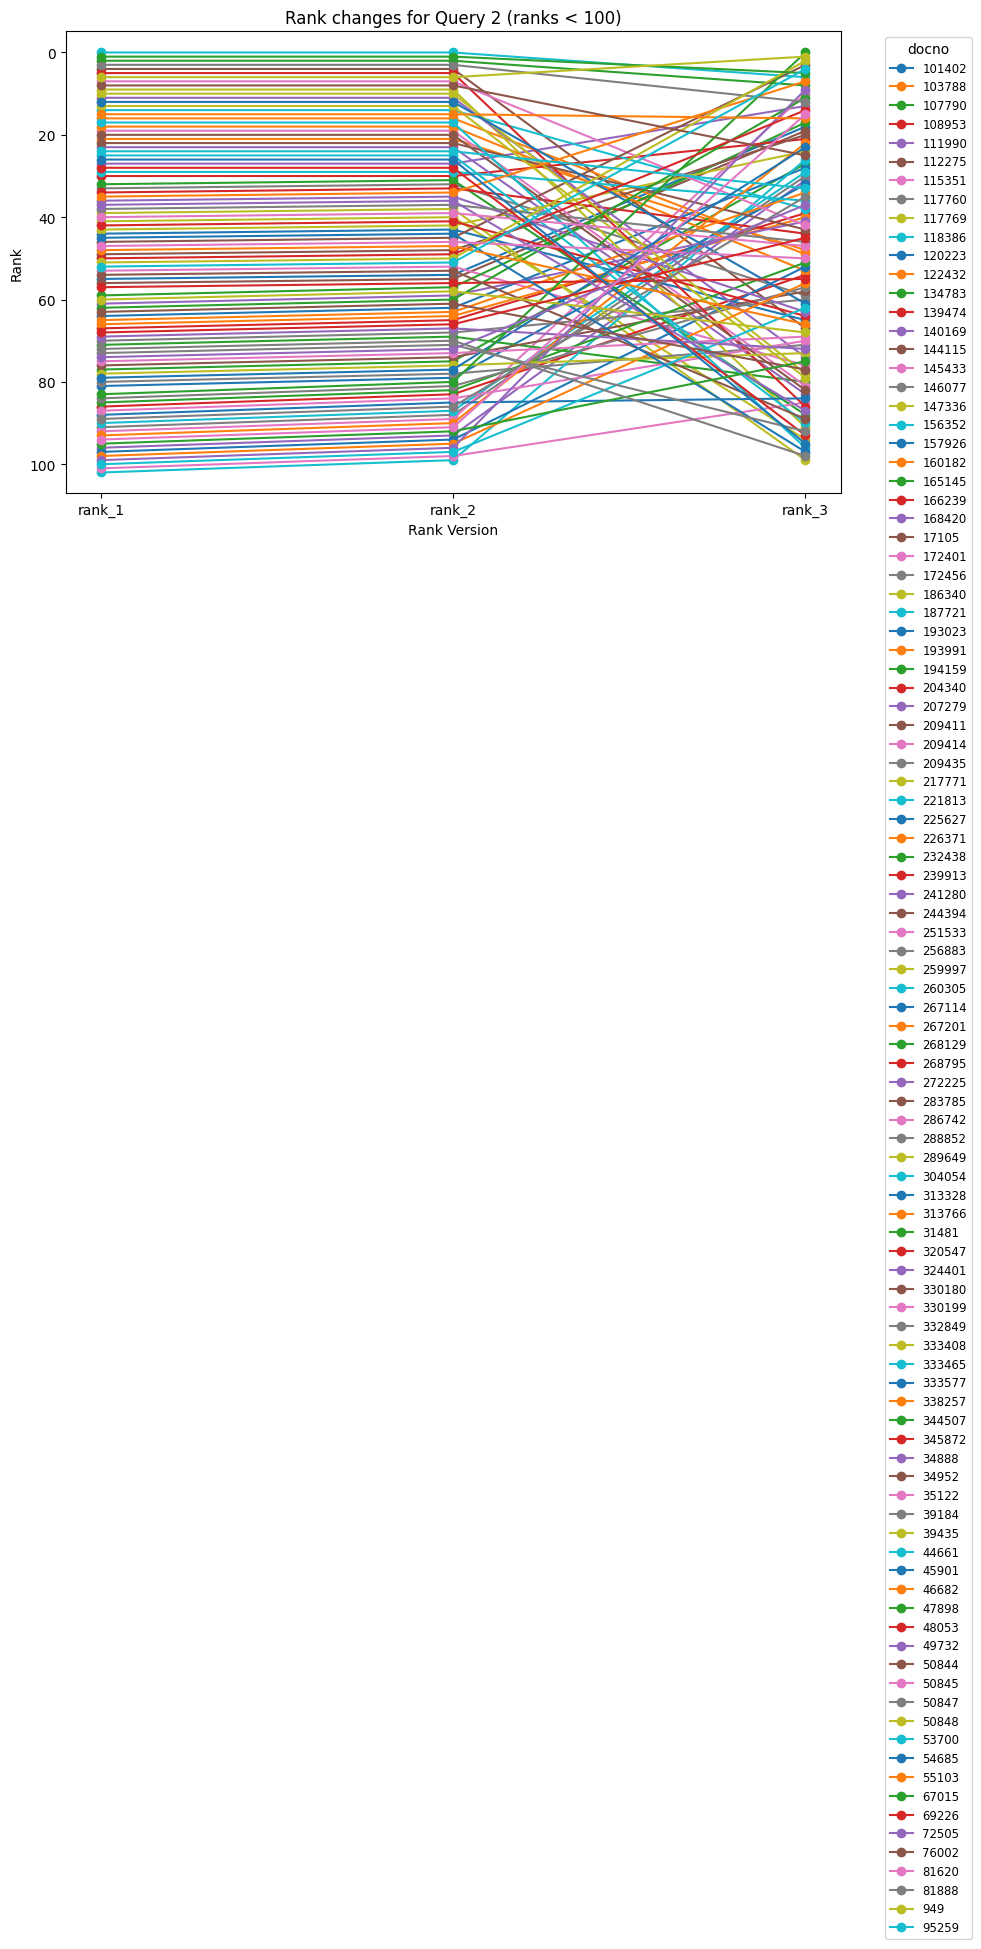

In [73]:
import matplotlib.pyplot as plt
import pandas as pd

lhs_run = lhs_run.rename(columns={"rank": "rank_1"})
middle_run = middle_run.rename(columns={"rank": "rank_2"})
rhs_run = rhs_run.rename(columns={"rank": "rank_3"})

# Merge df1 and df2 on ["docno", "query"] with left join (keep all df1 rows)
merged_12 = pd.merge(lhs_run, middle_run[["docno", "qid", "rank_2"]],
                     on=["docno", "qid"], how="left")

# Merge the result with df3 also as a left join
merged_all = pd.merge(merged_12, rhs_run[["docno", "qid", "rank_3"]],
                      on=["docno", "qid"], how="left")

merged = merged_all[["qid", "docno", "rank_1", "rank_2", "rank_3"]]

# Suppose your merged dataframe is called `df` and you want to plot for a specific query:
query_id = "2"
k = 100

# Filter data for this query
df_q = merged[merged['qid'] == query_id]
# Step 2: Keep only rows where any rank is less than k
df_q =   df[(df['qid'] == query_id) & (
        (df['rank_1'] < k) |
        (df['rank_2'] < k) |
        (df['rank_3'] < k) |
        (df['rank_2'].isna() & (df['rank_1'] < k))
    )
].copy()
# Step 3: Melt to long format for plotting
df_long = df_q.melt(id_vars='docno',
                    value_vars=['rank_1', 'rank_2', 'rank_3'],
                    var_name='rank_version',
                    value_name='rank_value')

# Step 4: Map version names to numeric x-axis
df_long['rank_version_num'] = df_long['rank_version'].map({
    'rank_1': 1,
    'rank_2': 2,
    'rank_3': 3
})

# Step 4: Numeric x-axis for version
df_long['rank_version_num'] = df_long['rank_version'].map({
    'rank_1': 1,
    'rank_2': 2,
    'rank_3': 3
})

plt.figure(figsize=(10, 6))

for docno, group in df_long.groupby('docno'):
    group_sorted = group.sort_values('rank_version_num')
    x = group_sorted['rank_version_num']
    y = group_sorted['rank_value']
    has_nan = y.isna().any()
    
    # Filter out NaNs for plotting (line segments between existing points)
    x_valid = x[~y.isna()]
    y_valid = y[~y.isna()]
    
    if len(x_valid) > 1:
        plt.plot(x_valid, y_valid,
                 linestyle='--' if has_nan else '-',
                 color='black' if has_nan else None,
                 marker='o', label=str(docno))

plt.xlabel('Rank Version')
plt.ylabel('Rank')
plt.title(f'Rank changes for Query {query_id} (ranks < {k})')
plt.xticks([1, 2, 3], ['rank_1', 'rank_2', 'rank_3'])
plt.gca().invert_yaxis()
plt.legend(title='docno', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()
